<a href="https://colab.research.google.com/github/AkankshaB123/forecasting/blob/main/Weekly_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Load Pandas
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# Lab 1 - Data Loading & Index Prep
* Load the department-sales.csv dataset into a DataFrame
* Convert the data index to yyyy-mm-dd format
* Set the index frequency to weekly (W-FRI)

# Setup

In [44]:
df = pd.read_csv("department-sales.csv", index_col = 0, parse_dates = True)
df.head()

,Weekly_Sales,IsHoliday
Date,,
05/02/2010,24924.50,False
12/02/2010,46039.49,True
19/02/2010,41595.55,False
26/02/2010,19403.54,False
05/03/2010,21827.90,False


In [45]:
df.index = pd.to_datetime(df.index, format = "%d/%m/%Y")
df.index

DatetimeIndex(['2010-02-05', '2010-02-12', '2010-02-19', '2010-02-26',
               '2010-03-05', '2010-03-12', '2010-03-19', '2010-03-26',
               '2010-04-02', '2010-04-09',
               ...
               '2012-08-24', '2012-08-31', '2012-09-07', '2012-09-14',
               '2012-09-21', '2012-09-28', '2012-10-05', '2012-10-12',
               '2012-10-19', '2012-10-26'],
              dtype='datetime64[ns]', name='Date', length=143, freq=None)

## freq = None

In [47]:
# Set the freq to weekly
df = df.asfreq("W-FRI")
df.index

DatetimeIndex(['2010-02-05', '2010-02-12', '2010-02-19', '2010-02-26',
               '2010-03-05', '2010-03-12', '2010-03-19', '2010-03-26',
               '2010-04-02', '2010-04-09',
               ...
               '2012-08-24', '2012-08-31', '2012-09-07', '2012-09-14',
               '2012-09-21', '2012-09-28', '2012-10-05', '2012-10-12',
               '2012-10-19', '2012-10-26'],
              dtype='datetime64[ns]', name='Date', length=143, freq='W-FRI')

# Lab 2 - Visualisation
* Plot weekly sales using the Weekly_Sales column and add a title to the chart
* Highlight holiday weeks with vertical dashed red lines

In [51]:
df.head(2)

,Weekly_Sales,IsHoliday
Date,,
2010-02-05,24924.50,False
2010-02-12,46039.49,True


# Weekly Sales

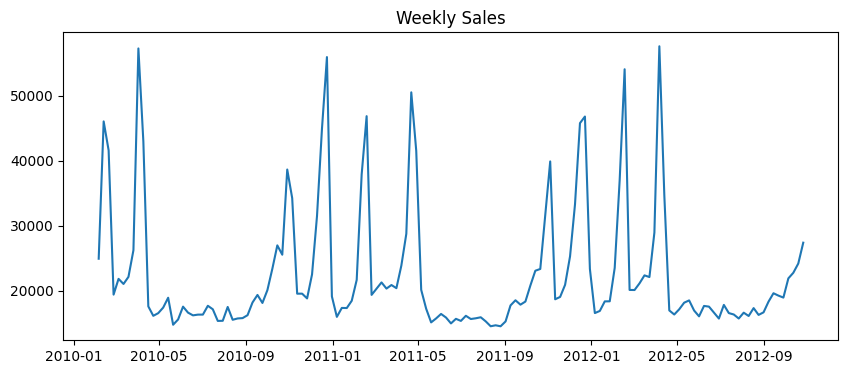

In [58]:
#Plot the weekly sales and add a title - Weekly Sales
plt.figure(figsize = (10,4))
plt.plot(df["Weekly_Sales"])
plt.title("Weekly Sales")
plt.show()

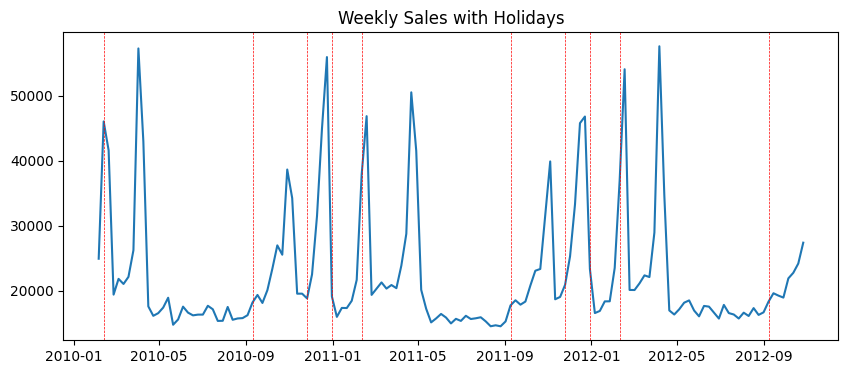

In [64]:
#Highlight holiday weeks with vertical dashed red lines
plt.figure(figsize = (10,4))
plt.plot(df["Weekly_Sales"])

for date, row in df.iterrows():
  if row["IsHoliday"] == 1:
    plt.axvline(x = date, color = "red", linestyle = "--", linewidth = '0.5')

plt.title("Weekly Sales with Holidays")
plt.show()

### Observation: Holidays are related to seasonal component or post-event softness after holidays is seen

# Exploratory Data Analysis for Time Series

# Lab 3 - ACF, PACF & Decomposition

* Plot the ACF of Weekly_Sales with 60 lags
* Plot the ACF of Weekly_Sales with 60 lags
* Perform multiplicative seasonal decomposition with period = 52

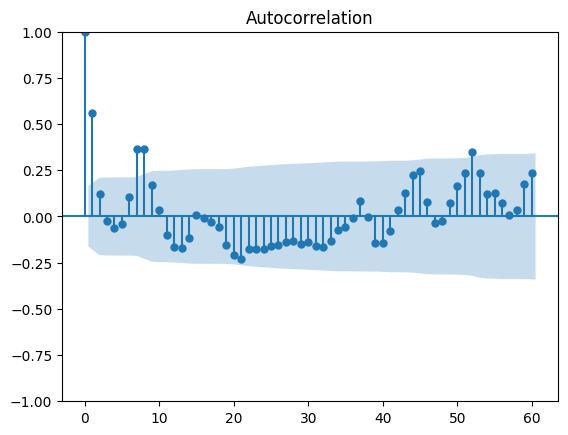

In [65]:
#Plot the ACF of Weekly_Sales with 60 lags
plot_acf(df["Weekly_Sales"], lags = 60)
plt.show()

Observation: (Left to Right Read)
* Immediately strike off: 7/8/9 week with a lot of info
* 1 yr before also info

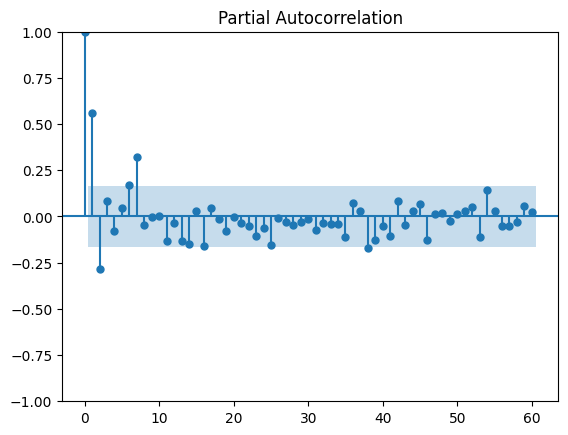

In [66]:
#PACF with 60 lags
plot_pacf(df.Weekly_Sales, lags = 60)
plt.show()

Observation:
* No relevant info 1 yr before
* Unique info - 7 weeks, post that not relevant enough

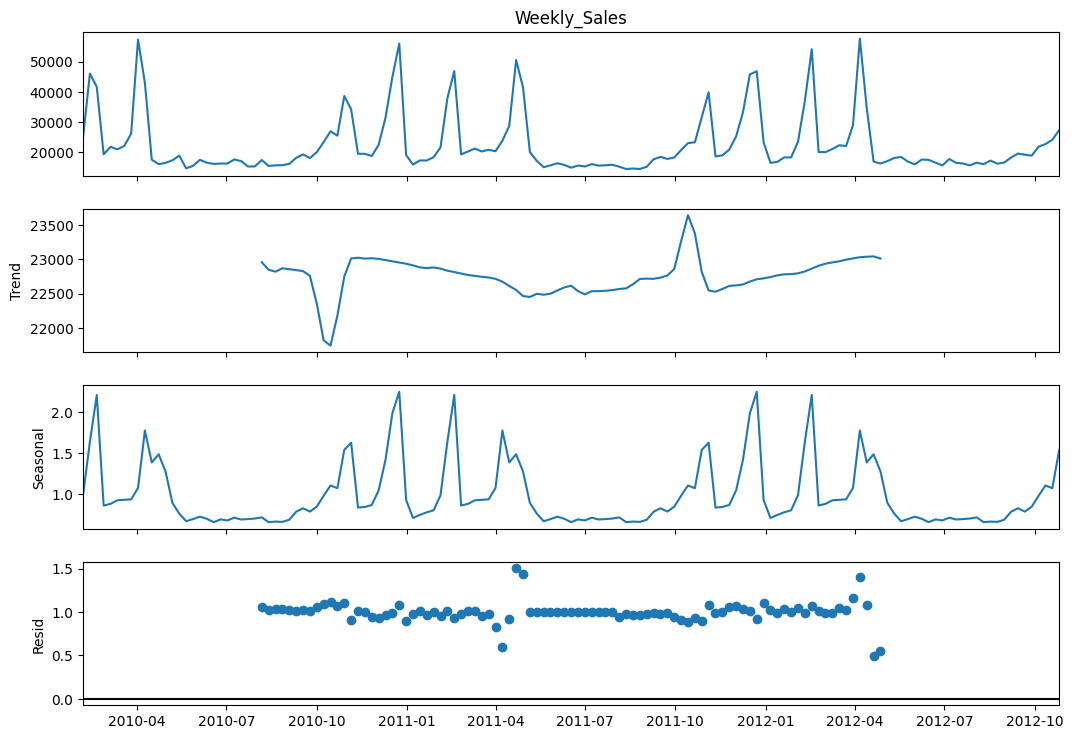

In [70]:
#Seasonal Decomposition, period = 52
decomposition = seasonal_decompose(df["Weekly_Sales"],
                            model = "multiplicative",
                            period = 52)
# result.plot(figsize = (10,4))
# plt.show()

#Let's build on this, not readable first draft, will get rid of double plotting.
fig = decomposition.plot()
fig.set_size_inches(12,8)
plt.show()

Observation:
* First 6 months no trend, last 6 months, no trend (weird trend)
* Seasonality - Above plot with holiday, seasonality may be affected